In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_csv("./data/GSL_compiled_ow_salinity_data_Oct2016_to_Feb2024.csv")
df2 = pd.read_csv("./data/GSLLevelVol.csv")
df2["sample_dt"] = df2["Date"]
df.set_index("sample_dt", inplace=True)
df2.set_index("sample_dt", inplace=True)
df = df.join(df2, how='inner')
df_copy = df.copy()

In [17]:
df = df_copy
north = df[df["portion"] == 'North']
south = df[df["portion"] == 'South_UBL']
north = north.groupby("sample_dt")[['salinity(g/L)']].mean()
south = south.groupby("sample_dt")[['salinity(g/L)']].mean()
data = df[['Date', 'S_level_m', 'N_level_m', 'S_vol_m3', 'N_vol_m3', 'Total_vol_m3', 'natlev_m', 'S_area_m2', 'N_area_m2']]
data.set_index("Date", inplace=True)
full = south.join(north, lsuffix='(south)', rsuffix='(north)').join(data)
full.drop_duplicates(inplace=True)
north_to_south_ratio = np.mean(full["salinity(g/L)(north)"]/full["salinity(g/L)(south)"])

masksouth = ~np.isnan(full["salinity(g/L)(south)"])
masknorth = ~np.isnan(full["salinity(g/L)(north)"])

full["salinity(g/L)(south)"] = full.where(cond=masksouth, other=full["salinity(g/L)(north)"]/north_to_south_ratio, axis=0)["salinity(g/L)(south)"]
full["salinity(g/L)(north)"] = full.where(cond=masknorth, other=full["salinity(g/L)(south)"]*north_to_south_ratio, axis=0)["salinity(g/L)(north)"]
full["avg_surface_salinity"] = (full["N_area_m2"]*full["salinity(g/L)(north)"] + full["S_area_m2"]*full["salinity(g/L)(south)"]) / (full["N_area_m2"] + full["S_area_m2"])
regress = linregress(full["natlev_m"], full["avg_surface_salinity"])
slope = regress[0]
intercept = regress[1]
full["sa"] = full["N_area_m2"] + full["S_area_m2"]
full = full.sort_values(by=["avg_surface_salinity"])[1:]

In [18]:
# volumes for which salinity data is available 
print(max(full["Total_vol_m3"]), min(full["Total_vol_m3"]))

13324068499.5497 9283784328.09906


In [19]:
full.columns

Index(['salinity(g/L)(south)', 'salinity(g/L)(north)', 'S_level_m',
       'N_level_m', 'S_vol_m3', 'N_vol_m3', 'Total_vol_m3', 'natlev_m',
       'S_area_m2', 'N_area_m2', 'avg_surface_salinity', 'sa'],
      dtype='object')

In [12]:
def get_vp_salinity_df(path="./data/vp-salinity.csv"):
    df = pd.read_csv(path)
    return df

def vp_reduction(salinity, df):
    return np.interp(salinity, df["salinity"], df["vp_reduction"])

df_es = get_vp_salinity_df()

In [23]:
full["es_reduction_direct"] = (full["N_area_m2"]*vp_reduction(full["salinity(g/L)(north)"], df_es) + full["S_area_m2"]*vp_reduction(full["salinity(g/L)(south)"], df_es)) / (full["N_area_m2"] + full["S_area_m2"])

In [24]:
full["es_reduction_indirect"] = vp_reduction(full["avg_surface_salinity"], df_es)

Text(0, 0.5, 'Reduction Ratio of Vapor Pressure')

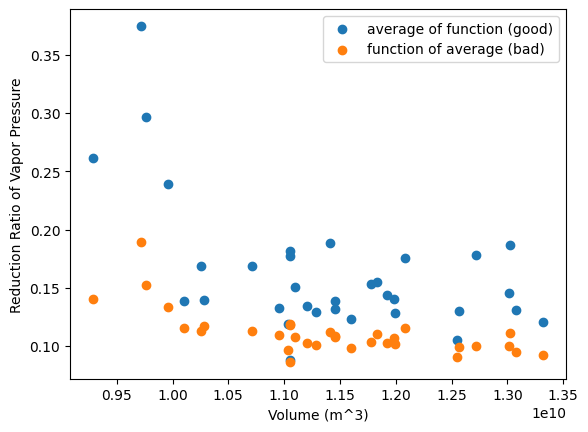

In [25]:
plt.scatter(full["Total_vol_m3"], full["es_reduction_direct"], label="average of function (good)")
plt.scatter(full["Total_vol_m3"], full["es_reduction_indirect"], label="function of average (bad)")
plt.legend()
plt.xlabel("Volume (m^3)")
plt.ylabel("Reduction Ratio of Vapor Pressure")

### Function to approximate Surface Salinity as a Function of Volume
$ SS(V) = aV^{-1} + bV^{-1/3}$

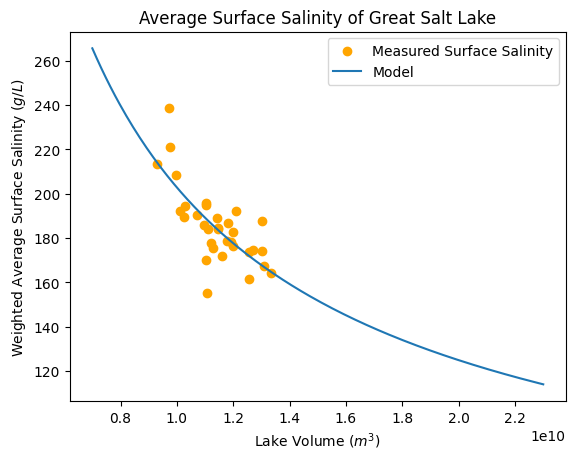

In [ ]:
model = LinearRegression(fit_intercept=False)
X = np.column_stack((full["Total_vol_m3"]**(-1), full["Total_vol_m3"]**(-1/3)))
model.fit(X, full["avg_surface_salinity"])
M_0, b = model.coef_
approx = model.predict(X)
approx = ((M_0 + b*(full["Total_vol_m3"]**(2/3))) / full["Total_vol_m3"])
plt.scatter(full["Total_vol_m3"], full["avg_surface_salinity"], color='orange', label="Measured Surface Salinity")
vol_domain = np.linspace(0.7e10, 2.3e10, 200)
X_sim = np.column_stack((vol_domain**(-1), vol_domain**(-1/3)))
approx2 = model.predict(X_sim)
plt.plot(vol_domain, approx2, label="Model")
#plt.scatter(full["Total_vol_m3"], approx)
plt.xlabel(rf"Lake Volume ($m^3$)")
plt.ylabel("Weighted Average Surface Salinity ($g/L$)")
plt.title("Average Surface Salinity of Great Salt Lake")
plt.legend()
plt.savefig("./images/surface_salinity_model.jpg")
plt.show()
a, b = model.coef_

In [36]:
a

1230618833073.342

In [37]:
b

171886.23798781837

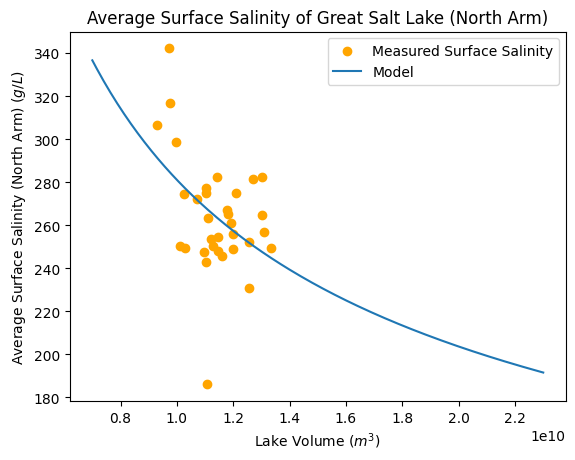

In [34]:
model = LinearRegression(fit_intercept=False)
X = np.column_stack((full["Total_vol_m3"]**(-1), full["Total_vol_m3"]**(-1/3)))
model.fit(X, full["salinity(g/L)(north)"])
M_0, b = model.coef_
approx = model.predict(X)
approx = ((M_0 + b*(full["Total_vol_m3"]**(2/3))) / full["Total_vol_m3"])
plt.scatter(full["Total_vol_m3"], full["salinity(g/L)(north)"], color='orange', label="Measured Surface Salinity")
vol_domain = np.linspace(0.7e10, 2.3e10, 200)
X_sim = np.column_stack((vol_domain**(-1), vol_domain**(-1/3)))
approx2 = model.predict(X_sim)
plt.plot(vol_domain, approx2, label="Model")
#plt.scatter(full["Total_vol_m3"], approx)
plt.xlabel(rf"Lake Volume ($m^3$)")
plt.ylabel("Average Surface Salinity (North Arm) ($g/L$)")
plt.title("Average Surface Salinity of Great Salt Lake (North Arm)")
plt.legend()
plt.savefig("./images/surface_salinity_model_north.jpg")
plt.show()
a_n, b_n = model.coef_

In [32]:
print(a_n, b_n)

662924936948.8833 462860.60460320744


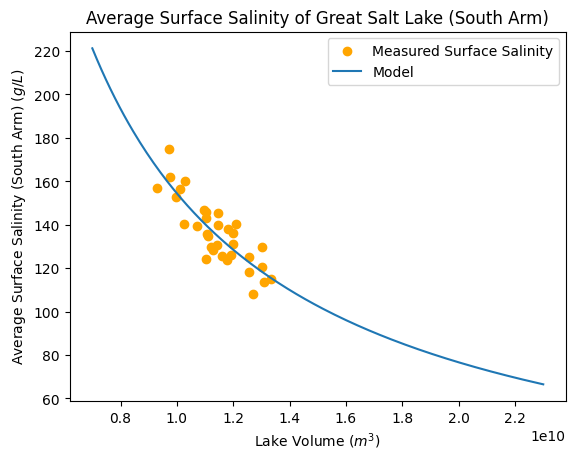

In [35]:
model = LinearRegression(fit_intercept=False)
X = np.column_stack((full["Total_vol_m3"]**(-1), full["Total_vol_m3"]**(-1/3)))
model.fit(X, full["salinity(g/L)(south)"])
M_0, b = model.coef_
approx = model.predict(X)
approx = ((M_0 + b*(full["Total_vol_m3"]**(2/3))) / full["Total_vol_m3"])
plt.scatter(full["Total_vol_m3"], full["salinity(g/L)(south)"], color='orange', label="Measured Surface Salinity")
vol_domain = np.linspace(0.7e10, 2.3e10, 200)
X_sim = np.column_stack((vol_domain**(-1), vol_domain**(-1/3)))
approx2 = model.predict(X_sim)
plt.plot(vol_domain, approx2, label="Model")
#plt.scatter(full["Total_vol_m3"], approx)
plt.xlabel(rf"Lake Volume ($m^3$)")
plt.ylabel("Average Surface Salinity (South Arm) ($g/L$)")
plt.title("Average Surface Salinity of Great Salt Lake (South Arm)")
plt.legend()
plt.savefig("./images/surface_salinity_model_south.jpg")
plt.show()
a_s, b_s = model.coef_

In [33]:
print(a_s, b_s)

1564606058225.5437 -4334.001932641948


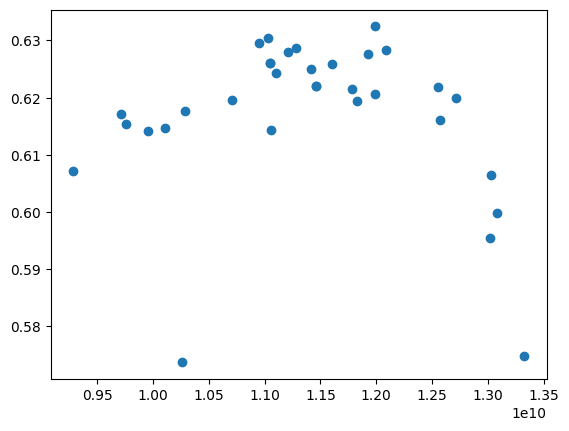

In [ ]:
full["North to South SA Ratio"] = full["N_area_m2"] / full["S_area_m2"]
plt.scatter(full["Total_vol_m3"], full["North to South SA Ratio"])
n_to_s_ratio = 0.615